# Speech / Music / Distress Classifier — YAMNet Transfer Learning Baseline

This notebook trains a quick baseline classifier on top of a frozen, pretrained
**YAMNet** model. YAMNet was trained on the full AudioSet ontology, so its
1,024-dimensional embeddings already encode a lot of what makes speech sound
like speech, music sound like music, and screaming sound like screaming — we
just need to train a small head on top of those embeddings using our own
`speech` / `music` / `distress` / `other` labels.

**Scope note:** this YAMNet-based model is a fast way to validate your data
and labeling scheme — it is *not* what will run on the ESP32. YAMNet itself is
a few megabytes, well past the microcontroller's budget. Once this baseline
confirms the data and classes are sound, the next step is training a much
smaller CNN from scratch (or distilling from this model) for the actual
embedded deployment.

In [2]:
!pip install tensorflow-hub

In [15]:
# If you don't have these yet:
# pip install tensorflow_hub scikit-learn matplotlib pandas

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
MANIFEST_PATH = 'audioset_subset/manifest.csv'  # adjust if your path differs

manifest_df = pd.read_csv(MANIFEST_PATH)
print(manifest_df.shape)
manifest_df.head()

(3265, 4)


,filepath,label,split,video_id
0,audioset_subset/train/speech/--PJHxphWEs.wav,speech,train,--PJHxphWEs
1,audioset_subset/train/speech/--aE2O5G5WE.wav,speech,train,--aE2O5G5WE
2,audioset_subset/train/other/--cB2ZVjpnA.wav,other,train,--cB2ZVjpnA
3,audioset_subset/train/other/--aaILOrkII.wav,other,train,--aaILOrkII
4,audioset_subset/train/music/-0DLPzsiXXE.wav,music,train,-0DLPzsiXXE


In [17]:
# Class balance per split under the 2-class setup: distress vs everything else
manifest_df = manifest_df.copy()
manifest_df['binary_label'] = manifest_df['label'].map(lambda x: 'distress' if x == 'distress' else 'other')
print(manifest_df.groupby(['split', 'binary_label']).size().unstack(fill_value=0))


binary_label  distress  other
split                        
test               130   1500
train              135   1500


In [18]:
CLASS_NAMES = ['distress', 'other']
label2id = {name: i for i, name in enumerate(CLASS_NAMES)}
id2label = {i: name for name, i in label2id.items()}

train_df = manifest_df[manifest_df['split'] == 'train'].reset_index(drop=True)
test_df = manifest_df[manifest_df['split'] == 'test'].reset_index(drop=True)

train_df = train_df.assign(label=train_df['binary_label'])
test_df = test_df.assign(label=test_df['binary_label'])

print(f'train clips: {len(train_df)}, test clips: {len(test_df)}')
print(train_df['label'].value_counts().to_string())


train clips: 1635, test clips: 1630
label
other       1500
distress     135


## Load YAMNet

Loading a model from TensorFlow Hub is a one-liner. The link still resolves
fine even though the TF Hub site itself now redirects to Kaggle Models.

In [19]:
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

## Build a tf.data pipeline that turns audio into YAMNet embeddings

YAMNet internally chops each clip into ~0.96s frames (0.48s hop) and returns
one embedding per frame. We treat each frame's embedding as its own training
example, inheriting the parent clip's label — this is free data augmentation,
and it matters here since the `distress` class has far fewer source clips
than `speech` or `music`.

In [20]:
def load_wav_16k_mono(filename):
    file_contents = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    return tf.squeeze(wav, axis=-1)


def extract_embeddings(wav_data, label):
    scores, embeddings, spectrogram = yamnet_model(wav_data)
    num_frames = tf.shape(embeddings)[0]
    return embeddings, tf.repeat(label, num_frames)


def make_dataset(df, shuffle=False, batch_size=32):
    filenames = df['filepath'].values
    labels = df['label'].map(label2id).values.astype('int64')

    ds = tf.data.Dataset.from_tensor_slices((filenames, labels))
    ds = ds.map(lambda f, l: (load_wav_16k_mono(f), l),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(extract_embeddings, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.unbatch()
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(2000)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(train_df, shuffle=True)
test_ds = make_dataset(test_df, shuffle=False)

In [21]:
## Validate YAMNet usage
# Sanity check: YAMNet is producing the embeddings that feed the head.
sample_path = train_df.loc[0, 'filepath']
sample_wav = load_wav_16k_mono(sample_path)
scores, embeddings, spectrogram = yamnet_model(sample_wav)
print('sample wav shape:', sample_wav.shape)
print('YAMNet scores shape:', scores.shape)
print('YAMNet embeddings shape:', embeddings.shape)
print('YAMNet spectrogram shape:', spectrogram.shape)
print('embedding mean/std:',
      float(tf.reduce_mean(embeddings)),
      float(tf.math.reduce_std(embeddings)))

for batch_x, batch_y in train_ds.take(1):
    print('train_ds batch input shape:', batch_x.shape)
    print('train_ds batch label shape:', batch_y.shape)
    break

assert batch_x.shape[-1] == 1024, 'Head input dim must match YAMNet embedding size'
print('Confirmed: head input dimension is 1024, matching YAMNet embeddings.')


sample wav shape: (160000,)
YAMNet scores shape: (20, 521)
YAMNet embeddings shape: (20, 1024)
YAMNet spectrogram shape: (1008, 64)
embedding mean/std: 0.04695550352334976 0.17320790886878967
train_ds batch input shape: (32, 1024)
train_ds batch label shape: (32,)
Confirmed: head input dimension is 1024, matching YAMNet embeddings.


I0000 00:00:1786233014.987278    1075 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9852002070474457194
I0000 00:00:1786233014.987381    1075 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 7005807629365379568
I0000 00:00:1786233014.987391    1075 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 529313679987638858
I0000 00:00:1786233014.987400    1075 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 2417235300438966966
I0000 00:00:1786233014.987410    1075 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 15022986056294532190
I0000 00:00:1786233014.987418    1075 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9448820144924722940
I0000 00:00:1786233014.987429    1075 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 10656081283582462678
I0000 00:00:1786233014.987437    1075 local_rendezvous.cc:432] Local rendezvous re

## Validate that YAMNet is actually producing embeddings for the head
This cell checks that YAMNet is being used to generate inputs, and that the
model training call is operating on those embeddings rather than raw audio.

In [22]:
# sanity check: YAMNet produces embeddings on real audio, and the dataset uses
# those embeddings as the head's inputs.
sample_path = train_df.loc[0, 'filepath']
sample_wav = load_wav_16k_mono(sample_path)
_, embeddings, _ = yamnet_model(sample_wav)
print('YAMNet embeddings shape:', embeddings.shape)
print('YAMNet embedding stats:',
      tf.reduce_min(embeddings).numpy(),
      tf.reduce_max(embeddings).numpy(),
      tf.reduce_mean(embeddings).numpy(),
      tf.math.reduce_std(embeddings).numpy())

for batch_x, batch_y in train_ds.take(1):
    print('train_ds batch input shape:', batch_x.shape)
    print('train_ds batch label shape:', batch_y.shape)
    print('train_ds embedding batch stats:',
          tf.reduce_mean(batch_x).numpy(),
          tf.math.reduce_std(batch_x).numpy())
    break

# compare embeddings for two different clips to confirm variability
sample_path2 = train_df.loc[1, 'filepath']
sample2_wav = load_wav_16k_mono(sample_path2)
_, embeddings2, _ = yamnet_model(sample2_wav)
print('mean embedding distance between two clips:',
      tf.norm(tf.reduce_mean(embeddings - embeddings2, axis=0)).numpy())

YAMNet embeddings shape: (20, 1024)
YAMNet embedding stats: 0.0 2.6375573 0.046955504 0.17320791
train_ds batch input shape: (32, 1024)
train_ds batch label shape: (32,)
train_ds embedding batch stats: 0.06568658 0.2415146
mean embedding distance between two clips: 2.8937123


W0000 00:00:1786233044.059433   31581 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
I0000 00:00:1786233044.082748    1075 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 2417235300438966966
I0000 00:00:1786233044.082808    1075 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 17965705209334449532
I0000 00:00:1786233044.082816    1075 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 2755026743121709742
I0000 00:00:1786233044.082813   31580 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 7344922960686747577
I0000 00:00:1786233044.082841   31580 local_rendezvous.cc:432] Local ren

In [29]:
# Clip-level class weights for the 2-class setup
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_df['label'].map(label2id).values,
)
class_weight_dict = dict(enumerate(class_weights))

# Manually adjust the distress class weight here.
# Increase this value to penalize missed distress examples more strongly.
distress_weight = 2.0
class_weight_dict[label2id['distress']] = distress_weight

print('class weights:')
for i, w in class_weight_dict.items():
    print(f'  {id2label[i]}: {w:.2f}')



class weights:
  distress: 2.00
  other: 0.55


## Train a small classification head on top of the frozen embeddings

YAMNet itself stays frozen — we're only training this small head, so this
trains fast even on CPU.

In [30]:
head = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024,), name='yamnet_embedding'),
    tf.keras.layers.Dense(256, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax'),
], name='distress_head')

head.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'],
)

head.summary()


Model: "distress_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,554 (1.13 MB)

 Trainable params: 295,554 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True
)

history = head.fit(
    train_ds,
    validation_data=test_ds,
    batch_size=32,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

Epoch 1/30


/home/josh/RATML/RATML_Hackathon/tf-env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786233400.756389   27432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_307171__.17


   1001/Unknown 4s 2ms/step - accuracy: 0.9673 - loss: 0.1088

I0000 00:00:1786233404.344088   27434 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_307171__.17


   1014/Unknown 5s 3ms/step - accuracy: 0.9657 - loss: 0.1114

...

I0000 00:00:1786233479.038134   61487 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11660503670397940687
I0000 00:00:1786233479.038185   61487 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 12658863443621831961


1005/1014 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9715 - loss: 0.0770

I0000 00:00:1786233481.581959   61422 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 5087331531773135841
I0000 00:00:1786233481.581998   61422 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11660503670397940687
I0000 00:00:1786233481.582015   61422 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 12658863443621831961


1014/1014 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9711 - loss: 0.0782 - val_accuracy: 0.5515 - val_loss: 1.2273


I0000 00:00:1786233483.505839   61487 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 11660503670397940687
I0000 00:00:1786233483.505886   61487 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 12658863443621831961


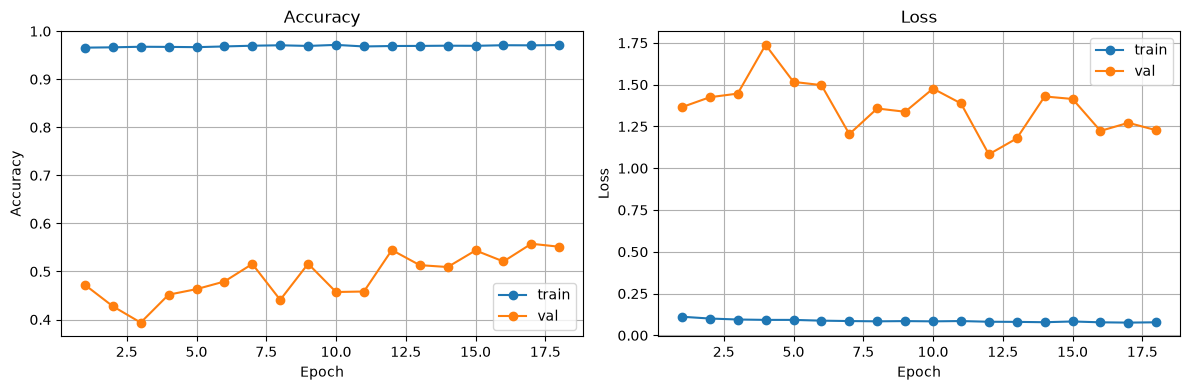

In [32]:
import matplotlib.pyplot as plt

def plot_history(history):
    h = history.history
    epochs = range(1, len(h.get("loss", [])) + 1)

    train_acc = h.get("accuracy") or h.get("acc")
    val_acc = h.get("val_accuracy") or h.get("val_acc")
    train_loss = h.get("loss")
    val_loss = h.get("val_loss")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    ax = axes[0]
    if train_acc is not None:
        ax.plot(epochs, train_acc, "o-", label="train")
    if val_acc is not None:
        ax.plot(epochs, val_acc, "o-", label="val")
    ax.set_title("Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)

    # Loss
    ax = axes[1]
    if train_loss is not None:
        ax.plot(epochs, train_loss, "o-", label="train")
    if val_loss is not None:
        ax.plot(epochs, val_loss, "o-", label="val")
    ax.set_title("Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage
plot_history(history)

## Evaluate — check per-class recall, not just overall accuracy

Overall accuracy can look great while the model quietly misses most
`distress` examples if that class is under-represented. Per-class recall on
`distress` is the number that actually matters for your use case.

In [33]:
y_true = []
y_pred = []

for embeddings, labels in test_ds:
    preds = head.predict(embeddings, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

    distress       0.14      0.90      0.24      2577
       other       0.98      0.51      0.67     29763

    accuracy                           0.54     32340
   macro avg       0.56      0.71      0.46     32340
weighted avg       0.92      0.54      0.64     32340



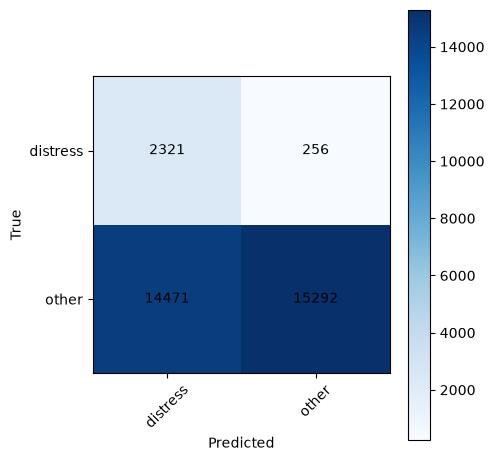

In [34]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Save the head (optional)

Just the small head — YAMNet itself doesn't need saving since you load it
fresh from TF Hub each time.

In [35]:
head.save('distress_head2.keras')

# Setup/Reload Model


In [17]:
import glob
import librosa
from IPython.display import Audio, display

# Reload in case this section is run standalone / after a kernel restart
if 'yamnet_model' not in dir():
    yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
if 'head' not in dir():
    head = tf.keras.models.load_model('distress_head.keras')

yamnet_classes = pd.read_csv(
    yamnet_model.class_map_path().numpy().decode('utf-8')
)['display_name'].values

In [18]:
def load_audio_any_format(filepath, target_sr=16000):
    """Loads any common audio format, resampling to mono 16kHz."""
    waveform, sr = librosa.load(filepath, sr=target_sr, mono=True)
    return waveform.astype(np.float32)


def predict_file(filepath, plot=True, play_audio=True, verbose=True):
    waveform = load_audio_any_format(filepath)

    scores, embeddings, spectrogram = yamnet_model(waveform)
    head_probs = head.predict(embeddings, verbose=0)  # (num_frames, num_classes)

    # our classifier's overall (clip-level) prediction, mean-pooled over frames
    mean_probs = head_probs.mean(axis=0)
    overall_class = CLASS_NAMES[np.argmax(mean_probs)]
    overall_conf = mean_probs.max()

    # what YAMNet's own 521-class output thinks, per frame - free sanity check
    yamnet_top = [yamnet_classes[i] for i in np.argmax(scores.numpy(), axis=1)]

    if verbose:
        print(filepath)
        print(f'  our model:  {overall_class}  ({overall_conf:.0%} confidence)')
        print(f'  yamnet says (most common frame label): '
              f'{pd.Series(yamnet_top).mode()[0]}')

    if play_audio:
        display(Audio(waveform, rate=16000))

    if plot:
        frame_times = np.arange(len(head_probs)) * 0.48  # YAMNet hop length
        plt.figure(figsize=(10, 3))
        plt.stackplot(frame_times, head_probs.T, labels=CLASS_NAMES, alpha=0.8)
        plt.legend(loc='upper right')
        plt.xlabel('Time (s)')
        plt.ylabel('Predicted probability')
        plt.title(f'{filepath.split("/")[-1]} — {overall_class} ({overall_conf:.0%})')
        plt.tight_layout()
        plt.show()

    return overall_class, overall_conf, head_probs

QUT 2.mp3
  our model:  distress  (85% confidence)
  yamnet says (most common frame label): Speech


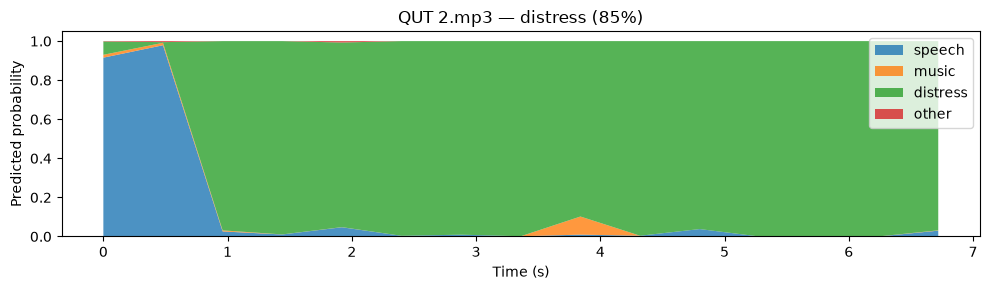

('distress',
 np.float32(0.85225797),
 array([[9.1527909e-01, 1.4553820e-02, 6.8268172e-02, 1.8989907e-03],
        [9.7877192e-01, 1.2475944e-02, 3.4811532e-03, 5.2709868e-03],
        [2.5923854e-02, 5.3802421e-03, 9.6864688e-01, 4.9055780e-05],
        [1.0350793e-02, 2.8414544e-04, 9.8932463e-01, 4.0468698e-05],
        [4.7336571e-02, 5.8502407e-04, 9.4487011e-01, 7.2082882e-03],
        [3.6308556e-03, 1.1594491e-05, 9.9635714e-01, 4.2959041e-07],
        [9.2630507e-03, 1.7362032e-05, 9.9071717e-01, 2.5097347e-06],
        [1.3325484e-03, 5.5317699e-08, 9.9866736e-01, 1.1932498e-07],
        [9.5189903e-03, 9.2701502e-02, 8.9777857e-01, 9.5151222e-07],
        [3.9390130e-03, 1.6424370e-05, 9.9604458e-01, 1.0412307e-08],
        [3.7994310e-02, 2.6098027e-05, 9.6197945e-01, 1.9073519e-07],
        [5.5239329e-05, 2.7204989e-05, 9.9991751e-01, 8.0753857e-08],
        [1.2391293e-04, 3.0074112e-05, 9.9984586e-01, 4.7957222e-08],
        [9.1253896e-05, 3.2365337e-04, 9.9958497e-01

In [ ]:
predict_file('clash_royale.mp3', plot=True, play_audio=True, verbose=True)

In [23]:
def predict_folder(folder_path, pattern='*.mp3'):
    results = []
    for filepath in sorted(glob.glob(f'{folder_path}/{pattern}')):
        overall_class, overall_conf, _ = predict_file(
            filepath, plot=False, play_audio=False, verbose=False
        )
        results.append({
            'file': filepath.split('/')[-1],
            'predicted': overall_class,
            'confidence': overall_conf,
        })
    return pd.DataFrame(results)

In [24]:
results_df = predict_folder('Recordings/')
results_df

,file,predicted,confidence
0,clash_royale.mp3,distress,0.828970
1,cough.mp3,speech,0.644479
2,earthquake_help.mp3,distress,0.852258
3,earthquake_help_far.mp3,distress,0.808418
4,female_distress.mp3,distress,0.964178
5,groan.mp3,distress,0.889757
6,heavy_breathing.mp3,distress,0.954432
7,hey_peter.mp3,distress,0.815371
8,high_help.mp3,distress,0.963206
9,high_help_far.mp3,distress,0.758707
